In [ ]:
# Import the FEMSystem Class from directory above
import sys
sys.path.append('../..')
from FEMSystem import FEMSystem

import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np
from jax.scipy.sparse.linalg import cg

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"


'''
Fill in File Path
'''
file_path1 = '../allplots/sepsweep3/sep1/results.pkl'
file_path2 = '../allplots/sepsweep3/sep15/results.pkl'

########################################################

pickled_obj = {}
with open(file_path1, 'rb') as f:
    pickled_obj1 = pickle.load(f)
    femsystem1:FEMSystem = pickled_obj1["femsystem"]
    femsystem1.saveFigsDir = None # Turn OFF saving plots
    u_even1,u_odd1 = pickled_obj1["u_even"],pickled_obj1["u_odd"]

    # Normalize the modes
    u_even1 = u_even1 / femsystem1.integrate(lambda u,a,b: u**2,u_even1)
    u_odd1 = u_odd1 / femsystem1.integrate(lambda u,a,b: u**2,u_odd1)

    u_even_interior1,u_odd_interior1 = u_even1[femsystem1.interior_dofs],u_odd1[femsystem1.interior_dofs]
    u_left_interior1,u_right_interior1 = (u_even_interior1+u_odd_interior1)/jnp.sqrt(2), (u_even_interior1-u_odd_interior1)/jnp.sqrt(2)

    n1,coeffs1 = pickled_obj1["n"],pickled_obj1["coeffs"]
    x1 = (n1-1)/2 - jnp.arange(n1)
with open(file_path2, 'rb') as f:
    pickled_obj2 = pickle.load(f)
    femsystem2:FEMSystem = pickled_obj2["femsystem"]
    femsystem2.saveFigsDir = None # Turn OFF saving plots
    u_even2,u_odd2 = pickled_obj2["u_even"],pickled_obj2["u_odd"]

    # Normalize the modes
    u_even2 = u_even2 / femsystem2.integrate(lambda u,a,b: u**2,u_even2)
    u_odd2 = u_odd2 / femsystem2.integrate(lambda u,a,b: u**2,u_odd2)

    u_even_interior2,u_odd_interior2 = u_even2[femsystem2.interior_dofs],u_odd2[femsystem2.interior_dofs]
    u_left_interior2,u_right_interior2 = (u_even_interior2+u_odd_interior2)/jnp.sqrt(2), (u_even_interior2-u_odd_interior2)/jnp.sqrt(2) 

    n2,coeffs2 = pickled_obj2["n"],pickled_obj2["coeffs"]
    x2 = (n2-1)/2 - jnp.arange(n2)

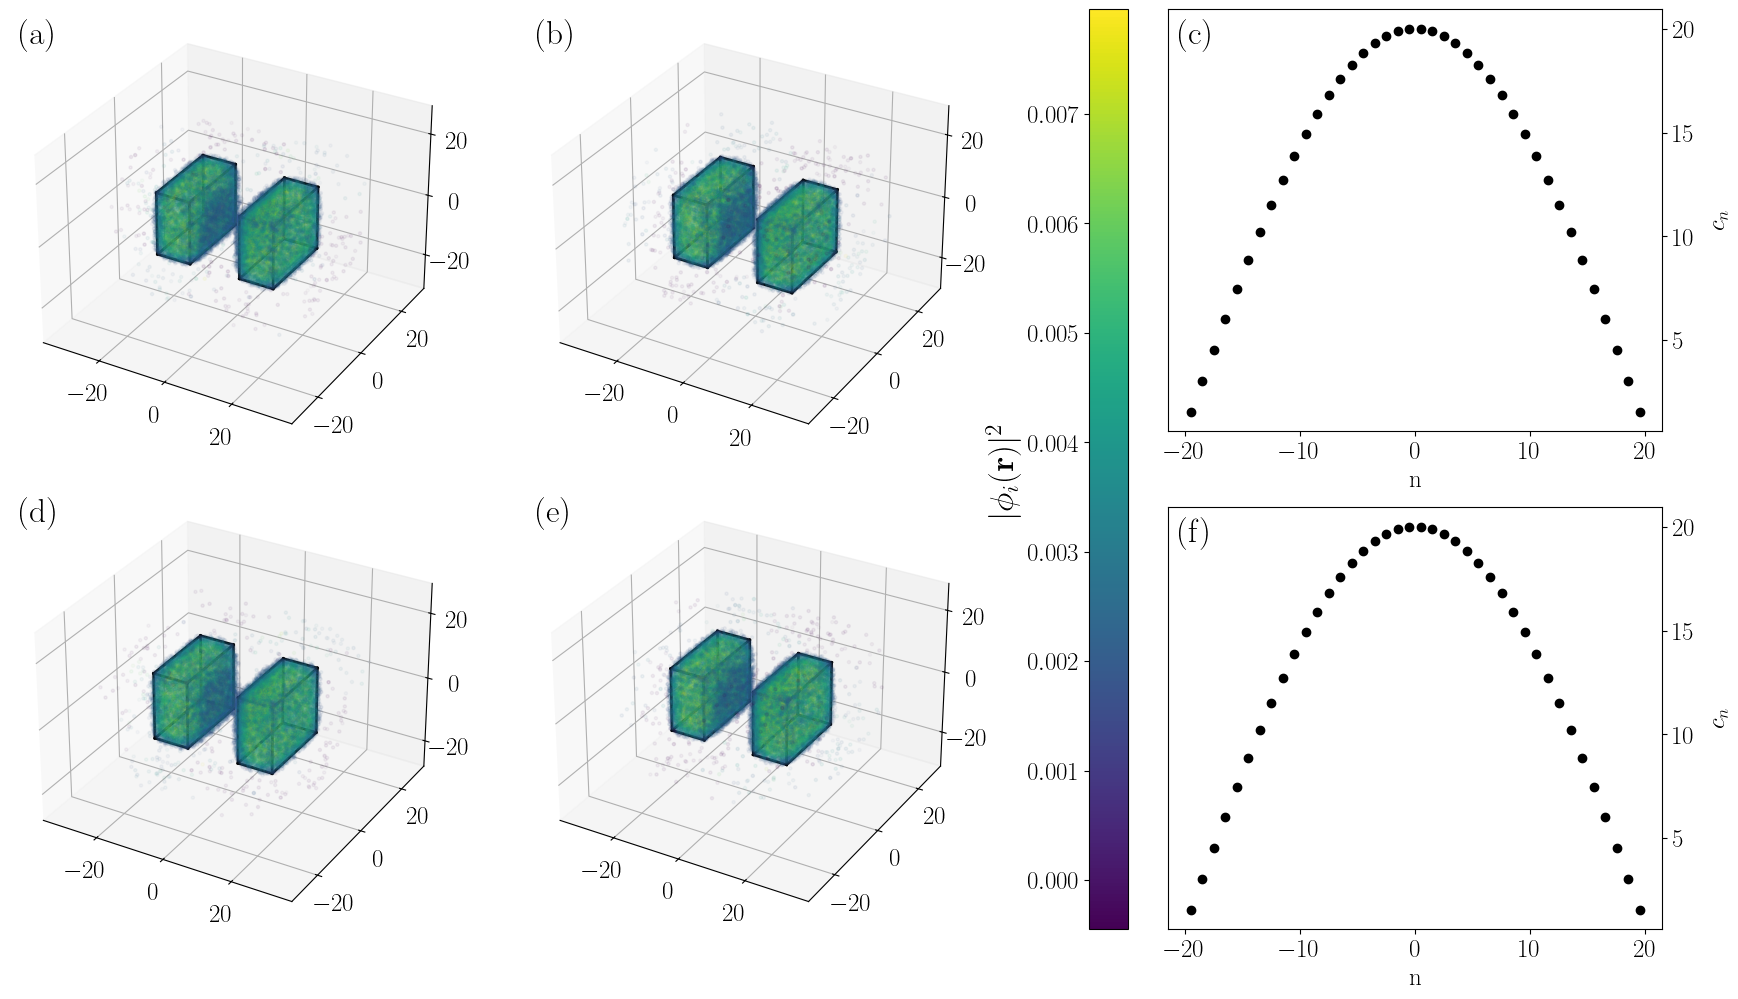

In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 18,
})

# Collect all values once to set one shared color mapping across all 4 heatmaps.
def quad_vals(femsystem, u_interior):
    u_global = femsystem._get_u_from_interior(u_interior)
    u_quad = femsystem._interpolate_values(u_global)
    return np.asarray(u_quad).ravel()

all_vals = np.concatenate([
    quad_vals(femsystem1, u_left_interior1),
    quad_vals(femsystem2, u_left_interior2),
    quad_vals(femsystem1, u_right_interior1),
    quad_vals(femsystem2, u_right_interior2),
])

# Keep robust range; switch to (all_vals.min(), all_vals.max()) if you prefer strict min/max.
vmin, vmax = np.percentile(all_vals, [1, 99])

fig = plt.figure(figsize=(18, 10), constrained_layout=False)

# Robust non-overlapping layout:
# - Left block: 2x2 heatmaps with zero internal horizontal gap.
# - Right block: thin colorbar column + coefficient column with explicit spacing.
outer = fig.add_gridspec(1, 2, width_ratios=[2.0, 1.0], wspace=0.03)
# Slight negative wspace pulls the two left heatmap columns closer.
left = outer[0, 0].subgridspec(2, 2, wspace=-0.18, hspace=0.08)
# More vertical spacing on right block prevents label/title collisions.
right = outer[0, 1].subgridspec(2, 2, width_ratios=[0.08, 1.0], wspace=0.15, hspace=0.18)

ax_a = fig.add_subplot(left[0, 0], projection="3d")
ax_b = fig.add_subplot(left[0, 1], projection="3d")
ax_d = fig.add_subplot(left[1, 0], projection="3d")
ax_e = fig.add_subplot(left[1, 1], projection="3d")
cax = fig.add_subplot(right[:, 0])
ax_c = fig.add_subplot(right[0, 1])
ax_f = fig.add_subplot(right[1, 1])

# Match styling from single.ipynb so the 4 heatmaps look the same.
threshold = 0.0017
max_points = 40000
wire_color = "black"
wire_linewidth = 2.0
opacity_power = 1.5
alpha_lo = 0.10
alpha_hi = 0.01

# Use matplotlib's default 3D depth ordering (better perspective occlusion).

def prism_args_from_pickled(pickled_obj):
    params = pickled_obj["parameters"]
    sidelenX = params["sidelenX"]
    sidelenY = params["sidelenY"]
    sidelenZ = params["sidelenZ"]
    separation = params["separation"]

    center_left = ((sidelenX + separation) / 2, 0, 0)
    center_right = (-(sidelenX + separation) / 2, 0, 0)
    prism_centers = [center_left, center_right]
    prism_side_lengths = [(sidelenX, sidelenY, sidelenZ), (sidelenX, sidelenY, sidelenZ)]
    return prism_centers, prism_side_lengths

prism_centers_1, prism_side_lengths_1 = prism_args_from_pickled(pickled_obj1)
prism_centers_2, prism_side_lengths_2 = prism_args_from_pickled(pickled_obj2)

# Directly call your original function, now drawing onto target axes.
_, _, sc_a = femsystem1.plot_interior_at_quad_3d_heatmap(
    u_left_interior1,
    plot_title="",
    vmin=vmin,
    vmax=vmax,
    max_points=max_points,
    value_threshold=threshold,
    alpha_lo=alpha_lo,
    alpha_hi=alpha_hi,
    prism_centers=prism_centers_1,
    prism_side_lengths=prism_side_lengths_1,
    wire_color=wire_color,
    wire_linewidth=wire_linewidth,
    opacity_power=opacity_power,
    ax=ax_a,
    add_colorbar=False,
)
_, _, _ = femsystem1.plot_interior_at_quad_3d_heatmap(
    u_right_interior1,
    plot_title="",
    vmin=vmin,
    vmax=vmax,
    max_points=max_points,
    value_threshold=threshold,
    alpha_lo=alpha_lo,
    alpha_hi=alpha_hi,
    prism_centers=prism_centers_1,
    prism_side_lengths=prism_side_lengths_1,
    wire_color=wire_color,
    wire_linewidth=wire_linewidth,
    opacity_power=opacity_power,
    ax=ax_b,
    add_colorbar=False,
)
_, _, _ = femsystem2.plot_interior_at_quad_3d_heatmap(
    u_left_interior2,
    plot_title="",
    vmin=vmin,
    vmax=vmax,
    max_points=max_points,
    value_threshold=threshold,
    alpha_lo=alpha_lo,
    alpha_hi=alpha_hi,
    prism_centers=prism_centers_2,
    prism_side_lengths=prism_side_lengths_2,
    wire_color=wire_color,
    wire_linewidth=wire_linewidth,
    opacity_power=opacity_power,
    ax=ax_d,
    add_colorbar=False,
)
_, _, _ = femsystem2.plot_interior_at_quad_3d_heatmap(
    u_right_interior2,
    plot_title="",
    vmin=vmin,
    vmax=vmax,
    max_points=max_points,
    value_threshold=threshold,
    alpha_lo=alpha_lo,
    alpha_hi=alpha_hi,
    prism_centers=prism_centers_2,
    prism_side_lengths=prism_side_lengths_2,
    wire_color=wire_color,
    wire_linewidth=wire_linewidth,
    opacity_power=opacity_power,
    ax=ax_e,
    add_colorbar=False,
)

# Shared colorbar in its own dedicated thin column.
mappable = plt.cm.ScalarMappable(norm=mcolors.Normalize(vmin=vmin, vmax=vmax), cmap=sc_a.cmap)
cbar = fig.colorbar(mappable, cax=cax)
# Put ticks/label on the left so nothing intrudes into coefficient panels.
cbar.ax.yaxis.set_ticks_position("left")
cbar.ax.yaxis.set_label_position("left")
cbar.set_label(r"$|\phi_i(\mathbf{r})|^2$", fontsize=24)

# Coefficient panels.
ax_c.plot(x1, coeffs1, ".", ms=12, color="black")
ax_c.set_title("")
ax_c.set_xlabel("n")
ax_c.set_ylabel("$c_n$", labelpad=8)
ax_c.yaxis.set_label_position("right")
ax_c.yaxis.tick_right()
ax_c.tick_params(axis="y", pad=4)

ax_f.plot(x2, coeffs2, ".", ms=12, color="black")
ax_f.set_title("")
ax_f.set_xlabel("n")
ax_f.set_ylabel("$c_n$", labelpad=8)
ax_f.yaxis.set_label_position("right")
ax_f.yaxis.tick_right()
ax_f.tick_params(axis="y", pad=4)
# Panel labels.
for ax, lab in zip([ax_a, ax_b, ax_c, ax_d, ax_e, ax_f], ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]):
    label_fontsize = 24
    if hasattr(ax, "text2D"):
        ax.text2D(
            0.02, 0.98, lab, 
            transform=ax.transAxes, 
            ha="left", va="top", fontsize=label_fontsize
        )
    else:
        ax.text(
            0.02, 0.98, lab, 
            transform=ax.transAxes, 
            ha="left", va="top", fontsize=label_fontsize
        )

fig.subplots_adjust(left=0.02, right=0.99, bottom=0.06, top=0.98)
fig.savefig("paper_fig_modes_coeffs.pdf", bbox_inches="tight")
plt.show()